In [ ]:
import os
import sys
import transformers
import torch
from xai_embeddings.models.BERT_model import BERT_model
from xai_embeddings.explainers.LOO_explainer import LOO_explainer
from xai_embeddings.explainers.subset_explainer import subset_explainer
from xai_embeddings.explainers.POS_permutation_explainer import POS_explainer
from xai_embeddings.explainers.attention_explainer import BertAttentionExplainer
from xai_embeddings.distances import euclidean_distance, cosine_distance



## Initialize Explainers

In [17]:
mod = BERT_model("bert-base-uncased")

spacy_path = "en_core_web_trf-3.8.0/en_core_web_trf/en_core_web_trf-3.8.0"
if os.path.exists(spacy_path):
    pos_pfi = POS_explainer(
        mod,
        pos_dict="pos_dictionary.pkl", # path to pos dictionary
        spacy=spacy_path, # path to spacy model
        n=100,
    )
    
loo = LOO_explainer(mod)
# you can change distance to euclidean_distance, cosine is default
subset = subset_explainer(mod, distance=euclidean_distance, max_subsets=100)
att = BertAttentionExplainer(mod, aggregation_method="sum")


/opt/anaconda/envs/clean_magisterka/lib/python3.12/site-packages/thinc/shims/pytorch.py:261: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f

## Explanation Objects

### One token

In [24]:
exp1 = loo.explainOne("When I was little I caught bass fish", 6)
print(exp1)


Explanation(type=LOO)


### Multiple tokens

In [ ]:

exp2 = loo.explainEmbeddings("When I was little I caught bass fish")
print(exp2)


Explanation(type=LOO)


Single word explanation share same object, but have only one token in explanation

In [28]:
print(len(exp1.scores), len(exp2.scores))


1 6


Scores are stored in dictionary with token position as a key

In [32]:
import json
print(json.dumps(exp1.scores, indent=2))



{
  "6": {
    "token": "bass",
    "intp": {
      "0": {
        "token": "when",
        "score": 0.021071791648864746
      },
      "1": {
        "token": "i",
        "score": 0.01590895652770996
      },
      "2": {
        "token": "was",
        "score": 0.02838188409805298
      },
      "3": {
        "token": "little",
        "score": 0.05455935001373291
      },
      "4": {
        "token": "i",
        "score": 0.06216853857040405
      },
      "5": {
        "token": "caught",
        "score": 0.23770153522491455
      },
      "7": {
        "token": "fish",
        "score": 0.6376758217811584
      }
    }
  }
}


Explanation Object also contain name of explainer, token list, original sentence

In [29]:
print("tokens", exp1.tokens)
print("sentence", exp1.sentence)
print("explainer", exp1.explanation_type)


tokens ['when', 'i', 'was', 'little', 'i', 'caught', 'bass', 'fish']
sentence When I was little I caught bass fish
explainer LOO


### Plot single barchart

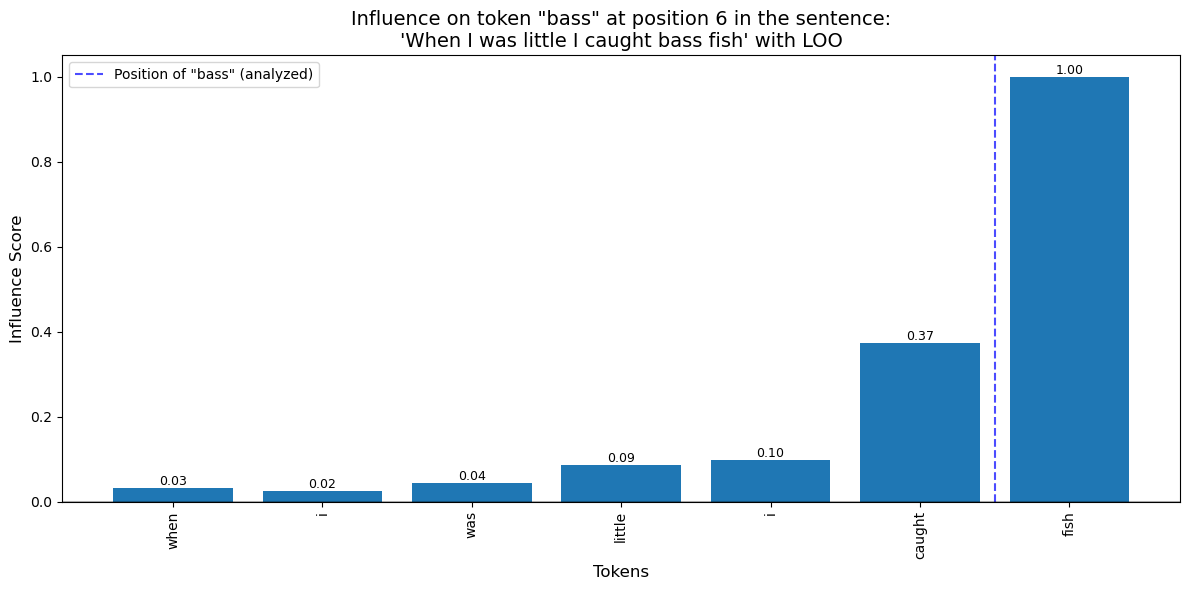

<module 'matplotlib.pyplot' from '/opt/anaconda/envs/clean_magisterka/lib/python3.12/site-packages/matplotlib/pyplot.py'>

In [18]:
loo.explainOne("When I was little I caught bass fish", 6).plot_one(
    6, show=True
)


### Circular Plot

[d3blocks] >INFO> Cleaning edge_properties and config parameters..
[d3blocks] >INFO> Cleaning edge_properties and config parameters..
[d3blocks] >INFO> Initializing [Chord]
[d3blocks] >INFO> filepath is set to [/tmp/d3blocks/temp_chord_diagram.html]
[d3blocks] >INFO> Convert to DataFrame.
[d3blocks] >INFO> Node properties are set.
[d3blocks] >INFO> Set edge-opacity based on the [source] node-opacity.
[d3blocks] >INFO> Set edge-colors based on the [source] node-color.
[d3blocks] >INFO> Edge properties are set.
[d3blocks] >INFO> File already exists and will be overwritten: [/tmp/d3blocks/temp_chord_diagram.html]


        target      source    weight
1          i:0        am:1  0.222635
2          i:0        an:2  0.116020
3          i:0   example:3  0.218792
4          i:0  sentence:4  0.130553
5          i:0         .:5  0.095678
6         am:1         i:0  0.443465
8         am:1        an:2  0.148084
9         am:1   example:3  0.175049
10        am:1  sentence:4  0.104719
11        am:1         .:5  0.066154
12        an:2         i:0  0.084573
13        an:2        am:1  0.166654
15        an:2   example:3  0.310997
16        an:2  sentence:4  0.109012
19   example:3        am:1  0.053595
20   example:3        an:2  0.174284
22   example:3  sentence:4  0.196115
25  sentence:4        am:1  0.063355
26  sentence:4        an:2  0.126168
27  sentence:4   example:3  0.458032
29  sentence:4         .:5  0.344446
30         .:5         i:0  0.067562
31         .:5        am:1  0.109058
32         .:5        an:2  0.092639
33         .:5   example:3  0.088596


[d3blocks] >INFO> Open browser: /tmp/d3blocks/temp_chord_diagram.html


SVG saved to temp_chord_diagram.svg


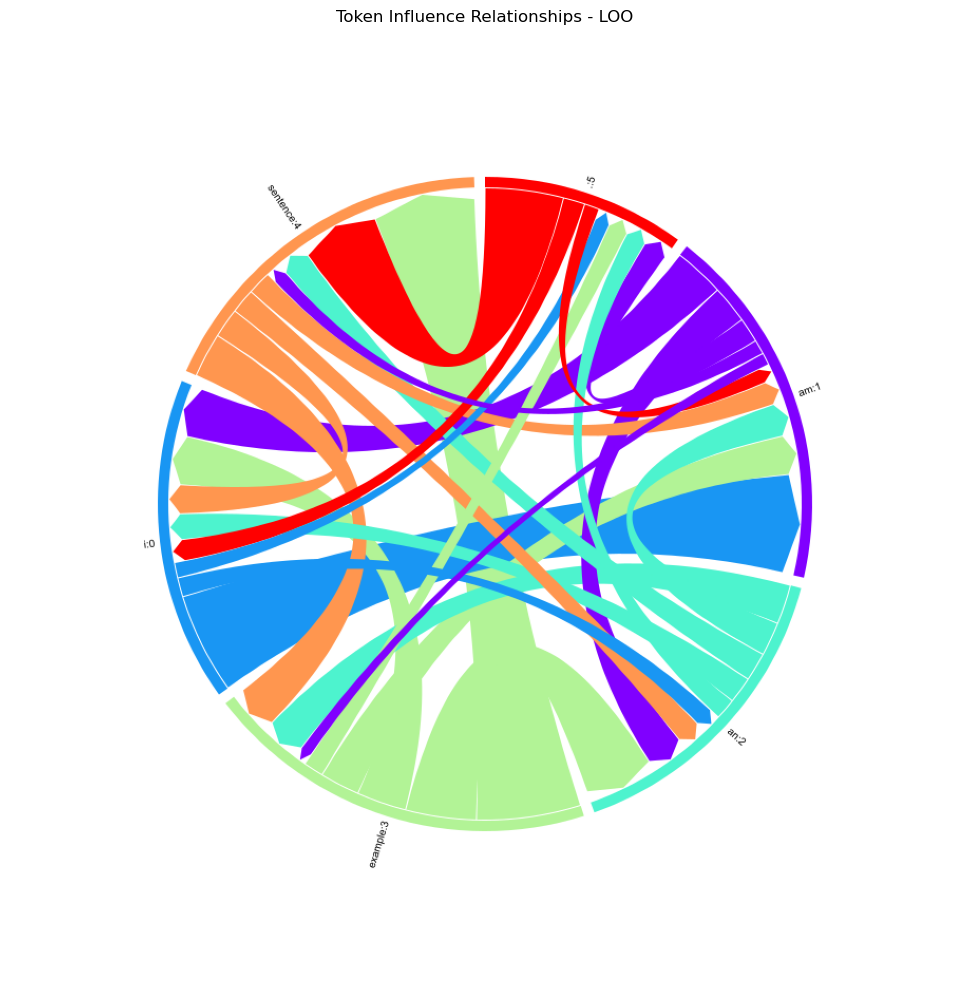

In [19]:
loo.explainEmbeddings('I am an example sentence .').plot_self_comparison(show=True)


### Comparison Plot 

Explaining token: "bass"


bass SHAP: 100%|██████████| 100/100 [00:36<00:00,  2.76subset/s]


Explaining token: "bass"


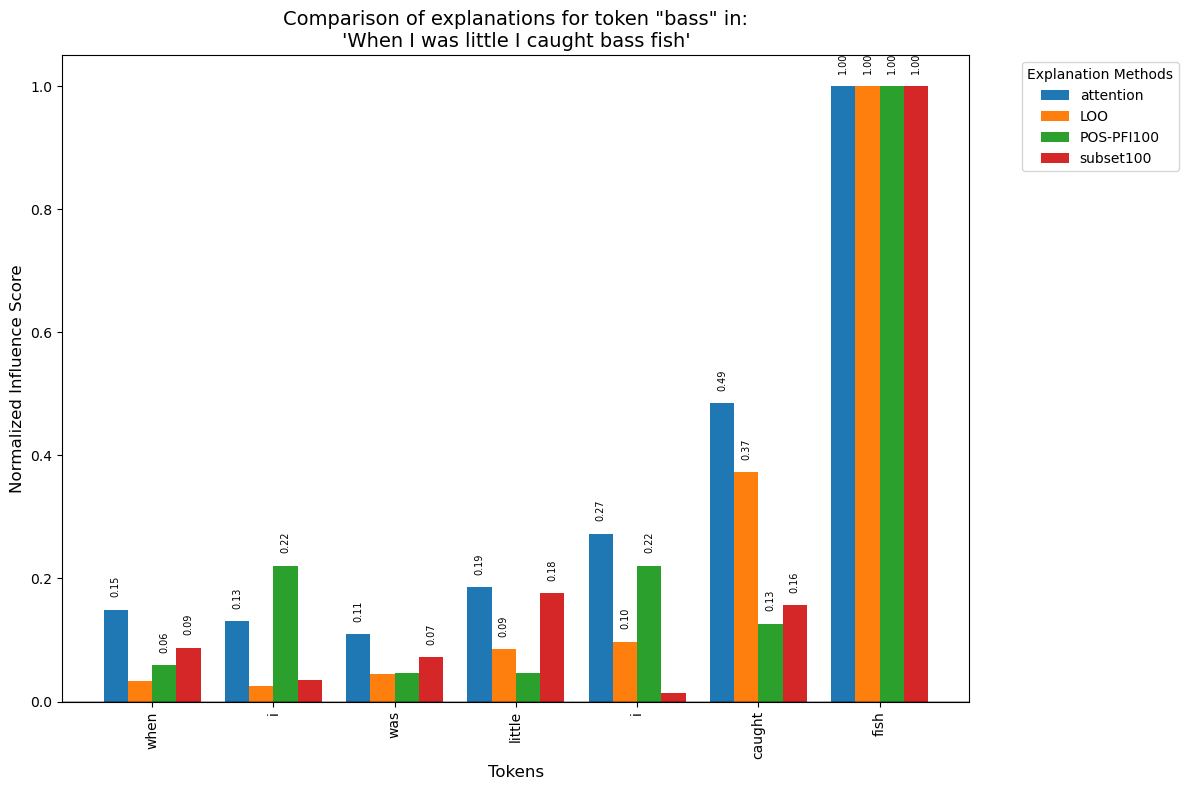

In [20]:
for n, i in enumerate(
        [
            # sentence, token idx
            ("When I was little I caught bass fish", 6),
        ]
    ):
        exps = []
        exps.append(loo.explainOne(i[0], i[1]))
        if 'pos_pfi' in locals():
            exps.append(pos_pfi.explainOne(i[0], i[1]))
        exps.append(subset.explainOne(i[0], i[1]))
        att.explainOne(i[0], i[1]).plot_comparison(
            i[1],
            *exps,
            show=True
        )
